In [1]:
import uproot
import polars as pl
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 18})
%config InlineBackend.figure_format = "retina"

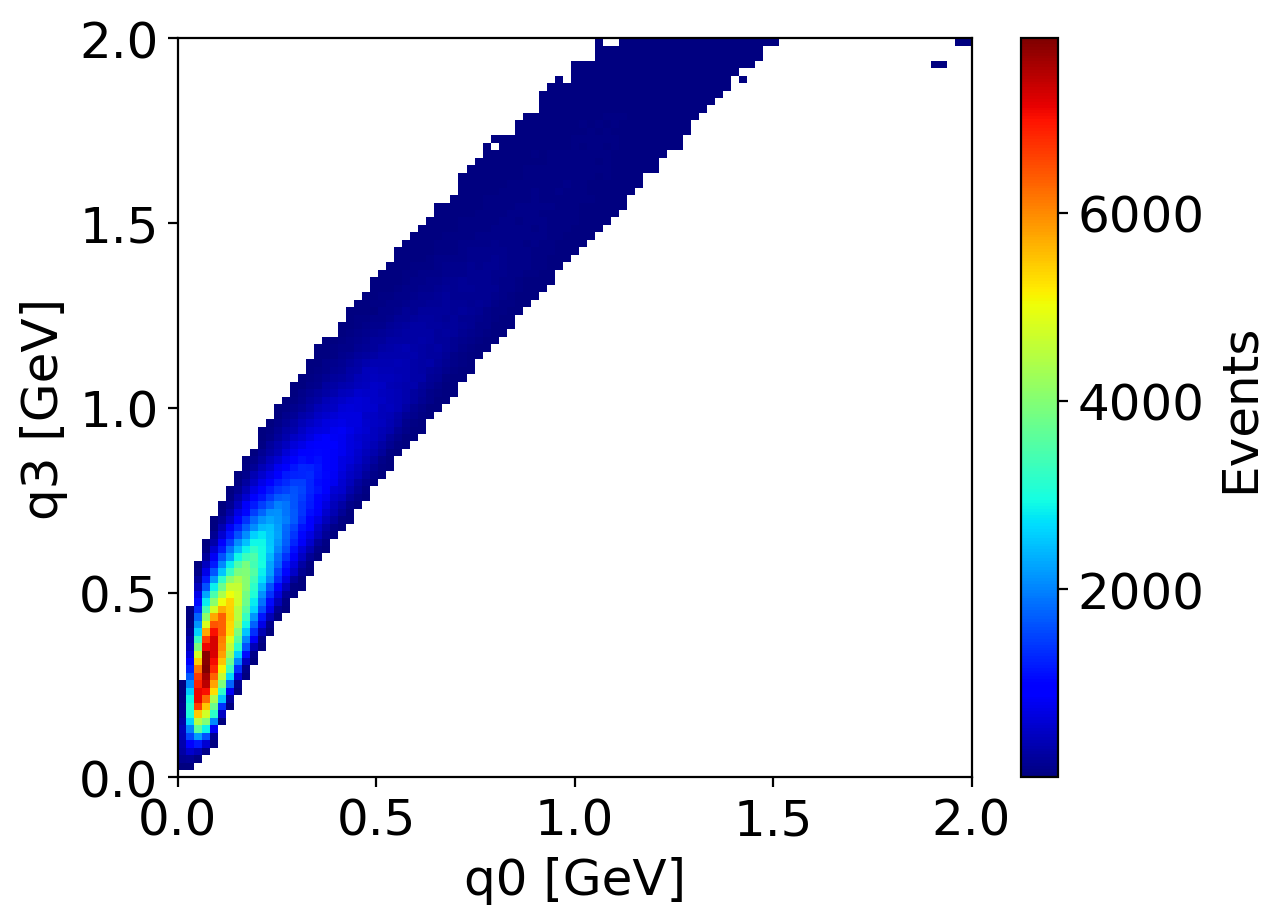

In [4]:
from scipy.stats import binned_statistic

numu_ccqe = genie_ccqe.filter(
    pl.col('pdg') == 14
).with_columns(
    direc_true = pl.col('nu_Py')/pl.col('nu_E'),
    direc_reco = pl.col('Pmu_y'),
    pmiss = (pl.col('hitnuc_Px')**2 + pl.col('hitnuc_Py')**2 + pl.col('hitnuc_Pz')**2).sqrt()*1000,
).with_columns(
    direc_res = (pl.col('direc_reco').arccos() - pl.col('direc_true').arccos())*180/np.pi
).filter(
    pl.col('direc_reco').abs() <= 1,
)
numu_ccqe.columns
plt.hist2d(numu_ccqe['q0'], numu_ccqe['q3'], bins=(np.linspace(0, 2, 100), np.linspace(0, 2, 100)), cmap='jet', cmin=1)
plt.xlabel('q0 [GeV]')
plt.ylabel('q3 [GeV]')
plt.colorbar(label='Events')

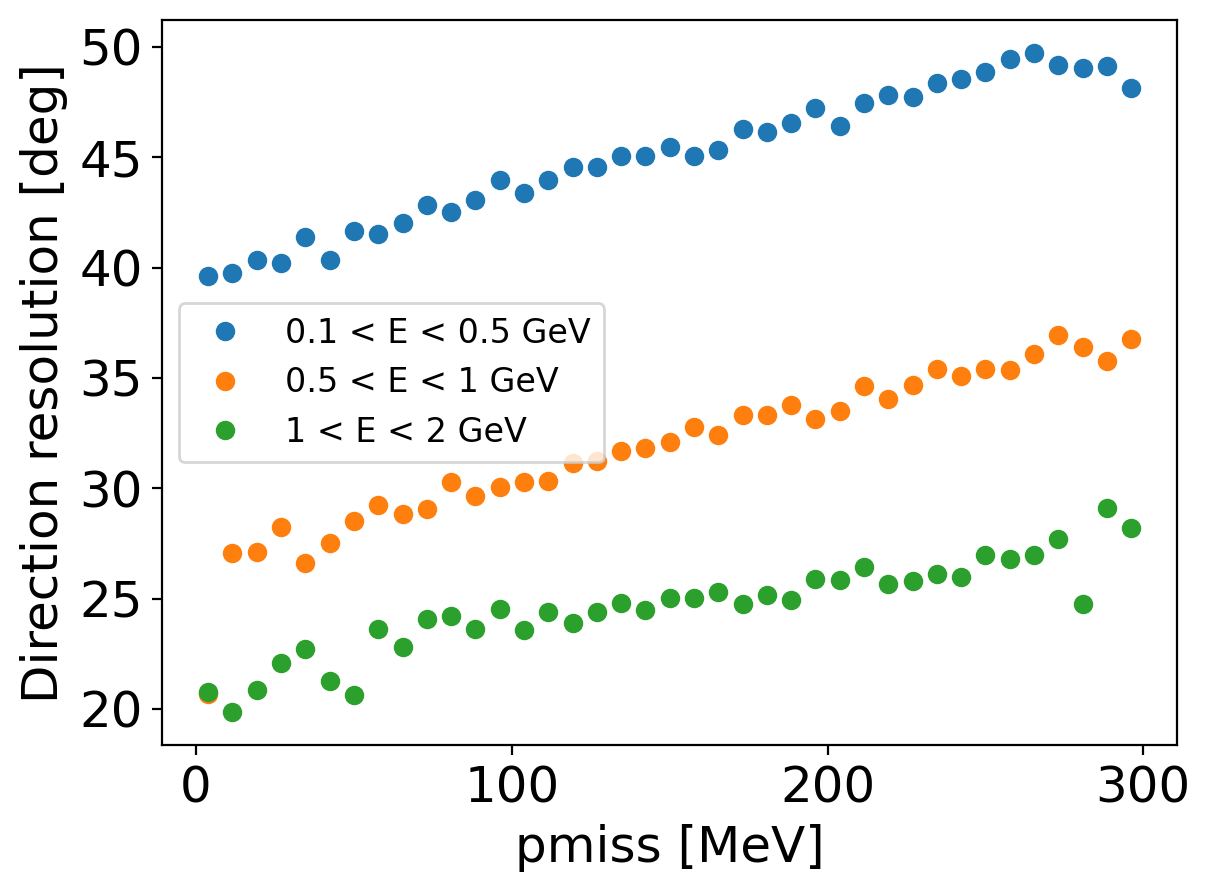

In [5]:
from scipy.stats import binned_statistic

numu_ccqe = genie_ccqe.filter(
    pl.col('pdg') == 14
).with_columns(
    direc_true = pl.col('nu_Py')/pl.col('nu_E'),
    direc_reco = pl.col('Pmu_y'),
    pmiss = (pl.col('hitnuc_Px')**2 + pl.col('hitnuc_Py')**2 + pl.col('hitnuc_Pz')**2).sqrt()*1000,
).with_columns(
    direc_res = (pl.col('direc_reco').arccos() - pl.col('direc_true').arccos())*180/np.pi
).filter(
    pl.col('direc_reco').abs() <= 1,
)

#Plotting the direction reco as a function of energy
# Ebins = np.linspace(0, 2, 40)
Pbins = np.linspace(0, 300, 40)
Ecenters = (Pbins[1:] + Pbins[:-1])/2
for Erange in ([0.1, 0.5], [0.5, 1], [1, 2]):
    selected = numu_ccqe.filter(
        pl.col('nu_E') > Erange[0],
        pl.col('nu_E') < Erange[1]
    )
    std = binned_statistic(selected['pmiss'], selected['direc_res'], statistic='std', bins=Pbins).statistic
    plt.errorbar(Ecenters, std, fmt='o', label=f'{Erange[0]} < E < {Erange[1]} GeV')
plt.xlabel('pmiss [MeV]')
plt.ylabel('Direction resolution [deg]')
plt.legend(fontsize=12)
plt.tight_layout()

Text(0.5, 0, 'Emiss [MeV]')

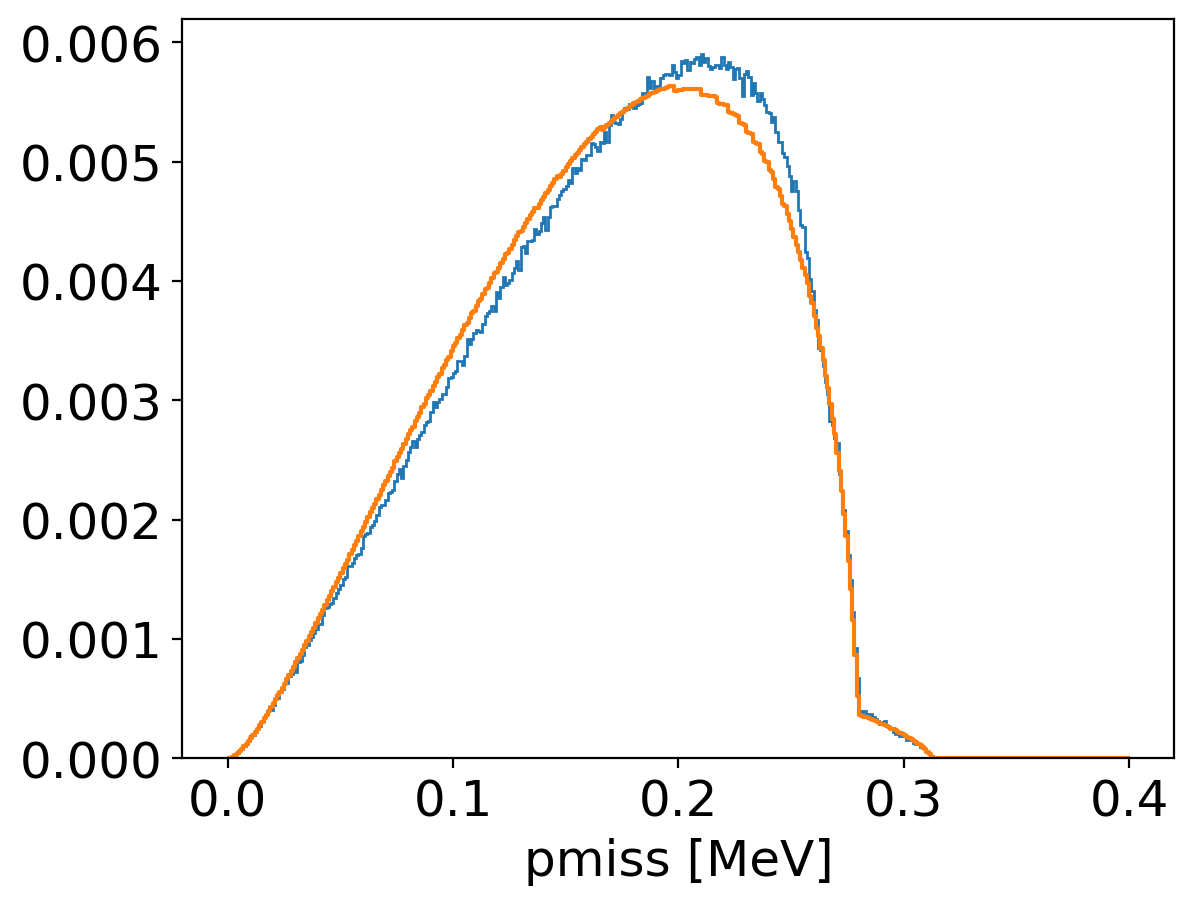

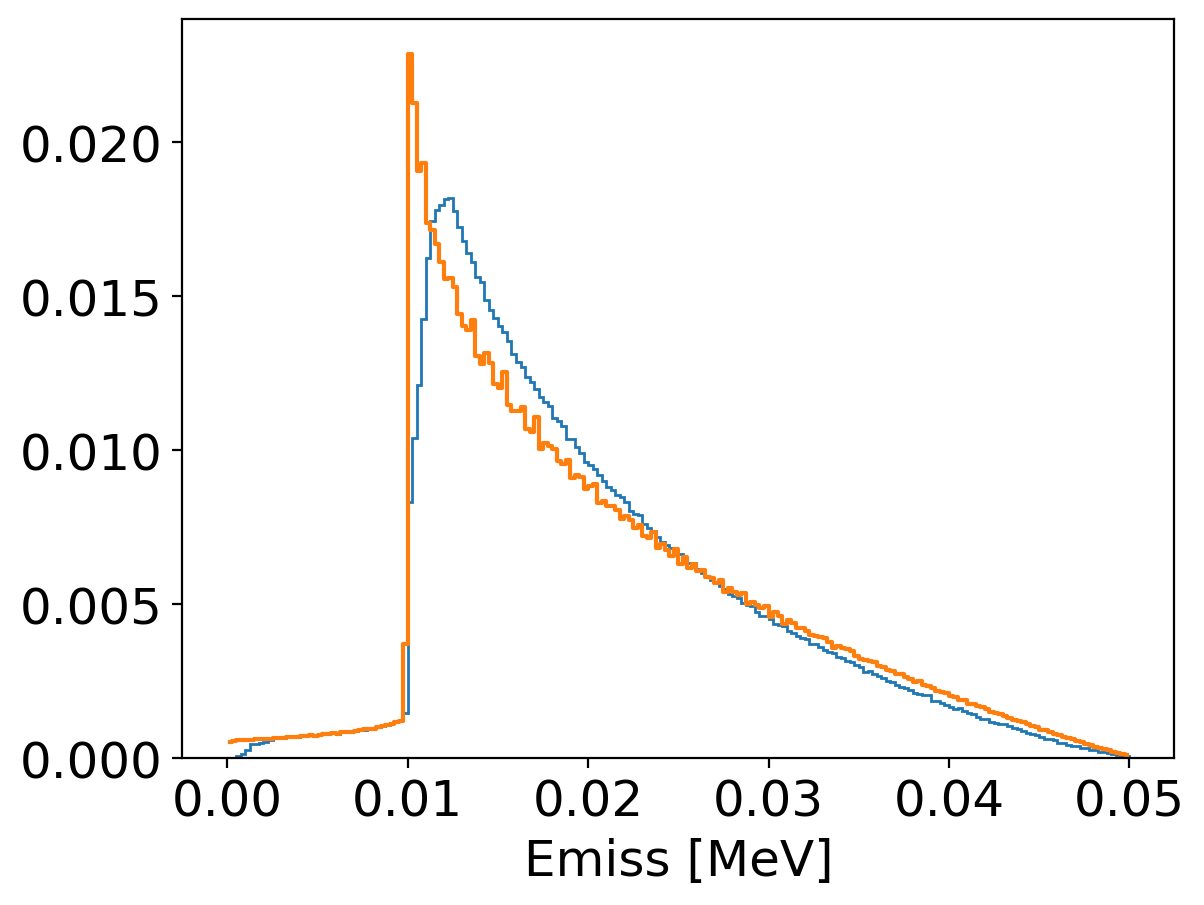

In [ ]:
# %matplotlib widget

with uproot.open('DIRT2_EmissWeights_validTree.root') as f:
    Eref_counts, Eref_bins = f['prob_e_py'].to_numpy()
    Eref_counts = Eref_counts / Eref_counts.sum()
    Pref_counts, Pref_bins = f['prob_px'].to_numpy()
    Pref_counts = Pref_counts / Pref_counts.sum()

nucleon_mass = 0.93956542052
data = genie_ccqe.with_columns(
    pmiss = (pl.col('hitnuc_Px')**2 + pl.col('hitnuc_Py')**2 + pl.col('hitnuc_Pz')**2).sqrt(),
    emiss = nucleon_mass - pl.col('hitnuc_E') ,
)

pbins = np.linspace(0, 0.4, 200)
ebins = np.linspace(0, 0.05, 200)
plt.figure()
plt.hist(data['pmiss'], Pref_bins, histtype='step', label='pmiss', weights=np.ones_like(data['pmiss'])/len(data['pmiss']));
plt.step(0.5*(Pref_bins[1:] + Pref_bins[:-1]), Pref_counts, where='mid', label='pmiss reference')
plt.xlabel('pmiss [MeV]')
plt.figure()
plt.hist(data['emiss'], Eref_bins, histtype='step', label='Emiss', weights=np.ones_like(data['emiss'])/len(data['emiss']));
plt.step(0.5*(Eref_bins[1:] + Eref_bins[:-1]), Eref_counts, where='mid', label='Emiss reference')
plt.xlabel('Emiss [MeV]')

/home/pgranger/.local/lib/python3.10/site-packages/polars/series/series.py:1464: RuntimeWarning: invalid value encountered in log
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),


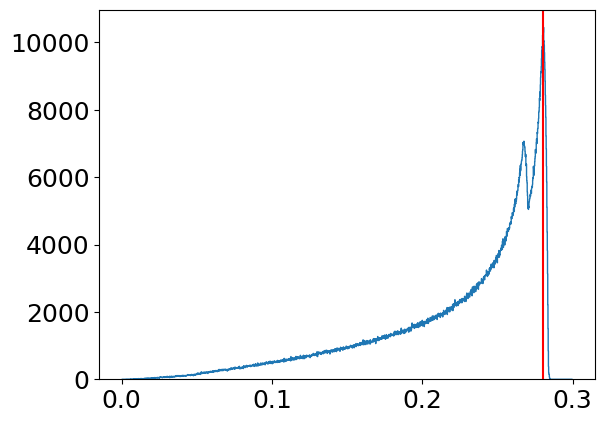

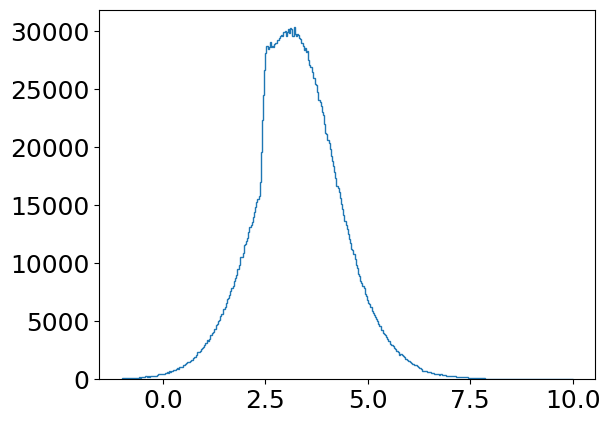

In [80]:

nucleon_mass = 0.93956542052
data = genie_ccqe.with_columns(
    pmiss = (pl.col('hitnuc_Px')**2 + pl.col('hitnuc_Py')**2 + pl.col('hitnuc_Pz')**2).sqrt(),
    emiss = nucleon_mass - pl.col('hitnuc_E') ,
).with_columns(
    KF = ((pl.col('emiss') + (pl.col('pmiss')**2 + nucleon_mass**2).sqrt() - 0.01)**2 - nucleon_mass**2).sqrt()
)

pbins = np.linspace(0, 0.30, 2000)
plt.hist(data['KF'], pbins, histtype='step', label='KF');
plt.axvline(0.280353400016503, color='r')

c = 3.53
z = 0.54
hbarc = 1.973269804e-16
fermi = 1.e-15/hbarc
def KftoR(kf):
    N = 22
    norm = (3./(4*np.pi*c**3))*(1./(1 + (np.pi*z/c)**2))
    return c + z*np.log((3*norm*N*(np.pi**2))/(fermi*kf)**3 - 1)
plt.figure()
plt.hist(KftoR(data['KF']), bins=np.linspace(-1, 10, 400), histtype='step', label='R');

In [79]:
KftoR(data['KF']).sort()

/home/pgranger/.local/lib/python3.10/site-packages/polars/series/series.py:1464: RuntimeWarning: invalid value encountered in log
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),


KF
f64
-3.684666
-3.684666
-3.684666
-3.684666
-3.684666
…
NaN
NaN
NaN


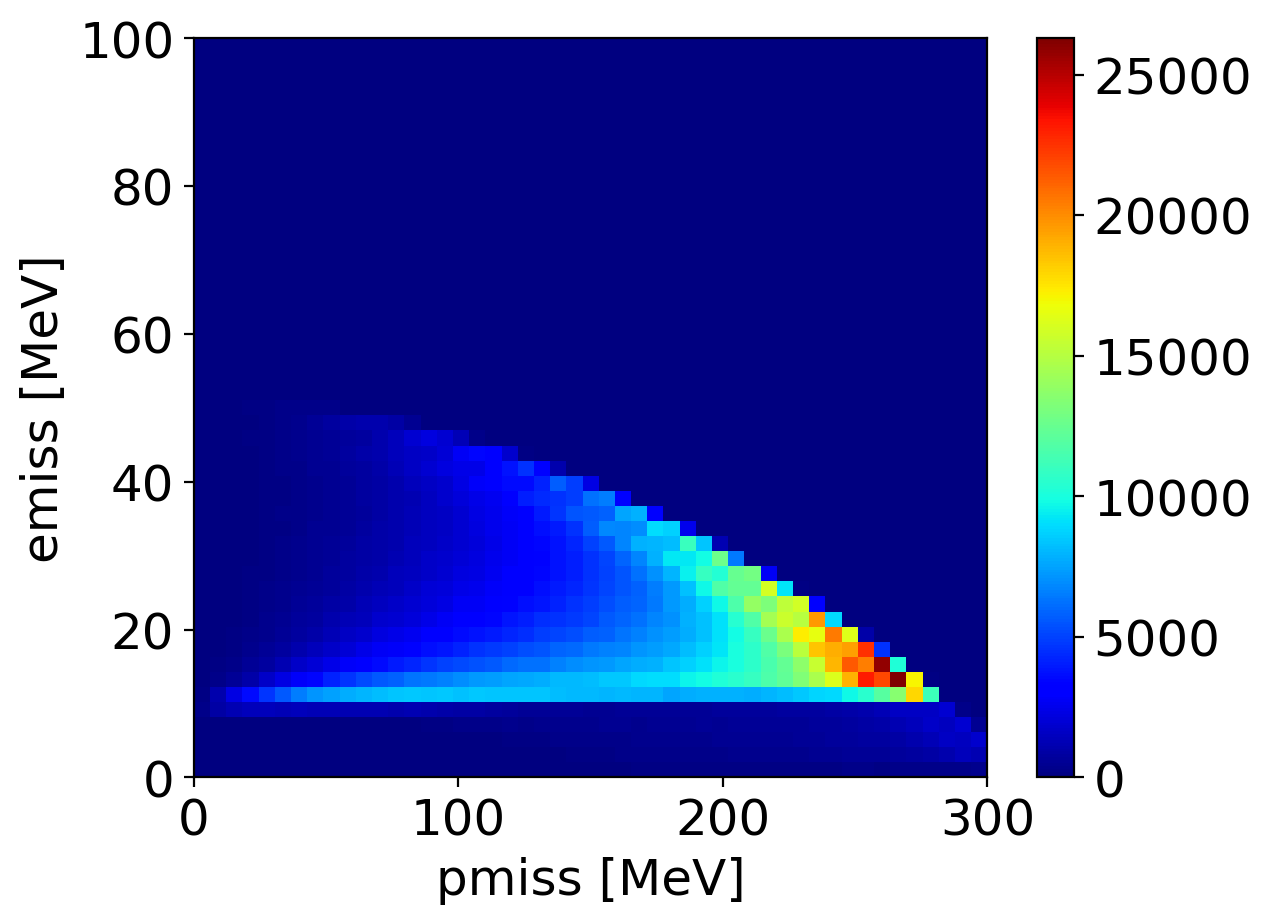

In [8]:
# %matplotlib widget

nucleon_mass = 0.93956542052
data = genie_ccqe.with_columns(
    pmiss = (pl.col('hitnuc_Px')**2 + pl.col('hitnuc_Py')**2 + pl.col('hitnuc_Pz')**2).sqrt(),
    emiss = nucleon_mass - pl.col('hitnuc_E') ,
)

pbins = np.linspace(0, 300, 50)
ebins = np.linspace(0, 100, 50)
plt.figure()
plt.hist2d(data['pmiss']*1000, data['emiss']*1000, bins=(pbins, ebins), cmap='jet');
plt.xlabel('pmiss [MeV]')
plt.ylabel('emiss [MeV]')
plt.colorbar()

sigma_limit 1.4769965
sigma limit: 0.68440294


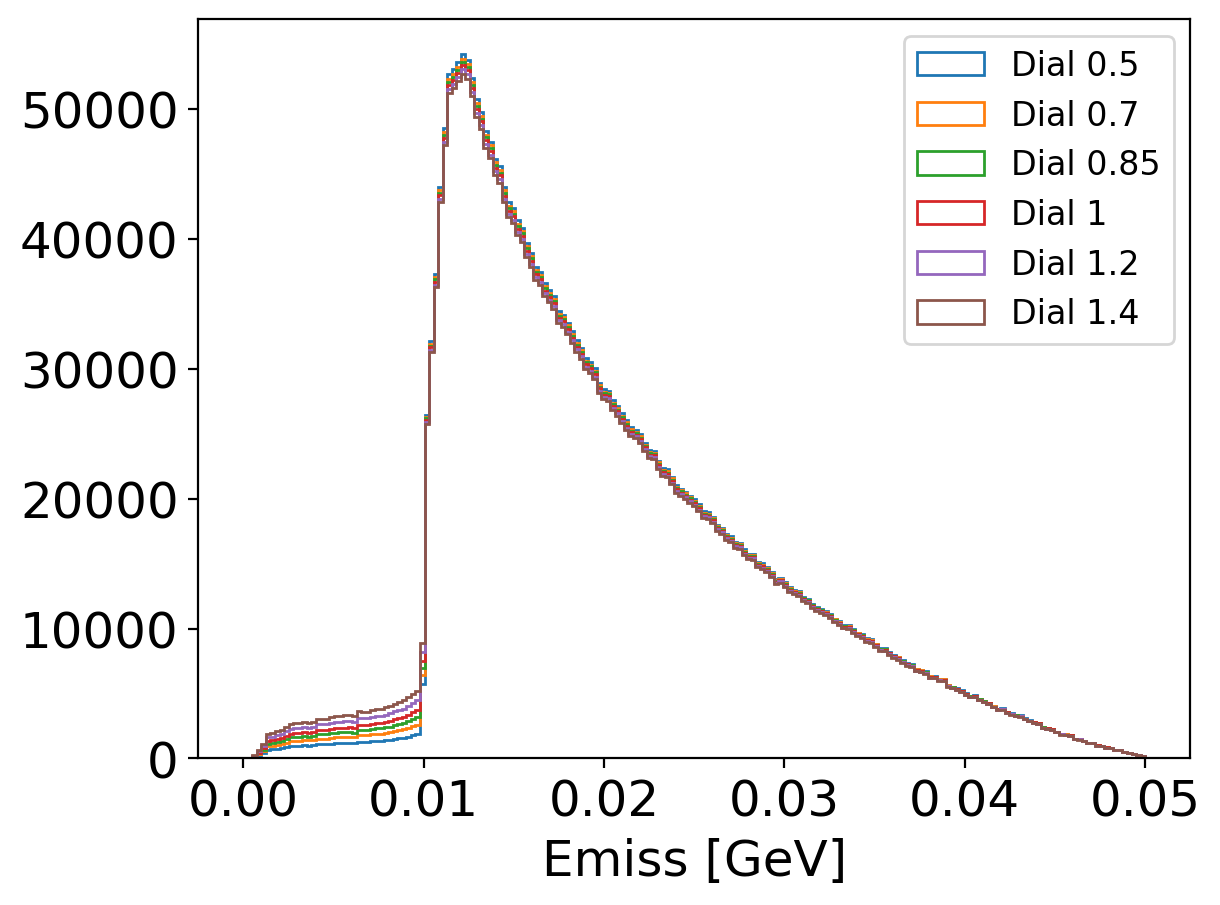

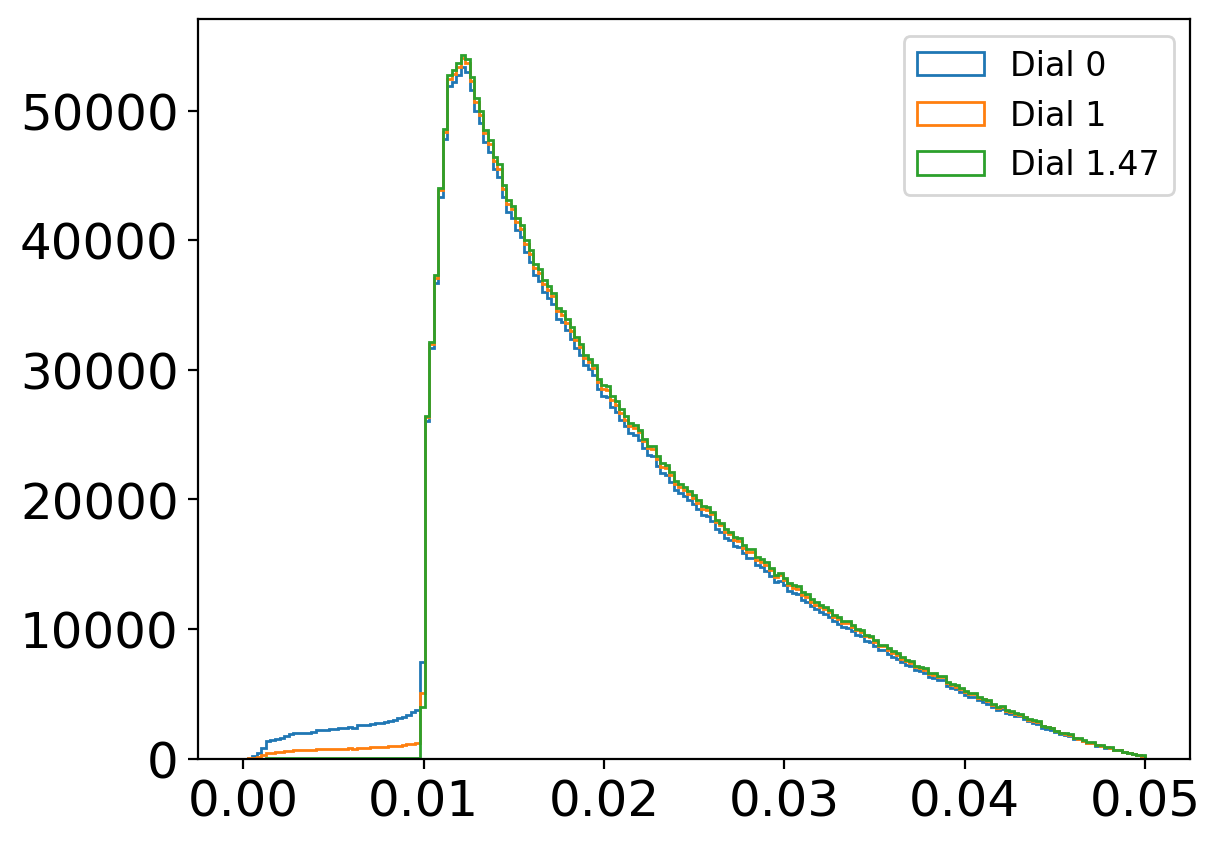

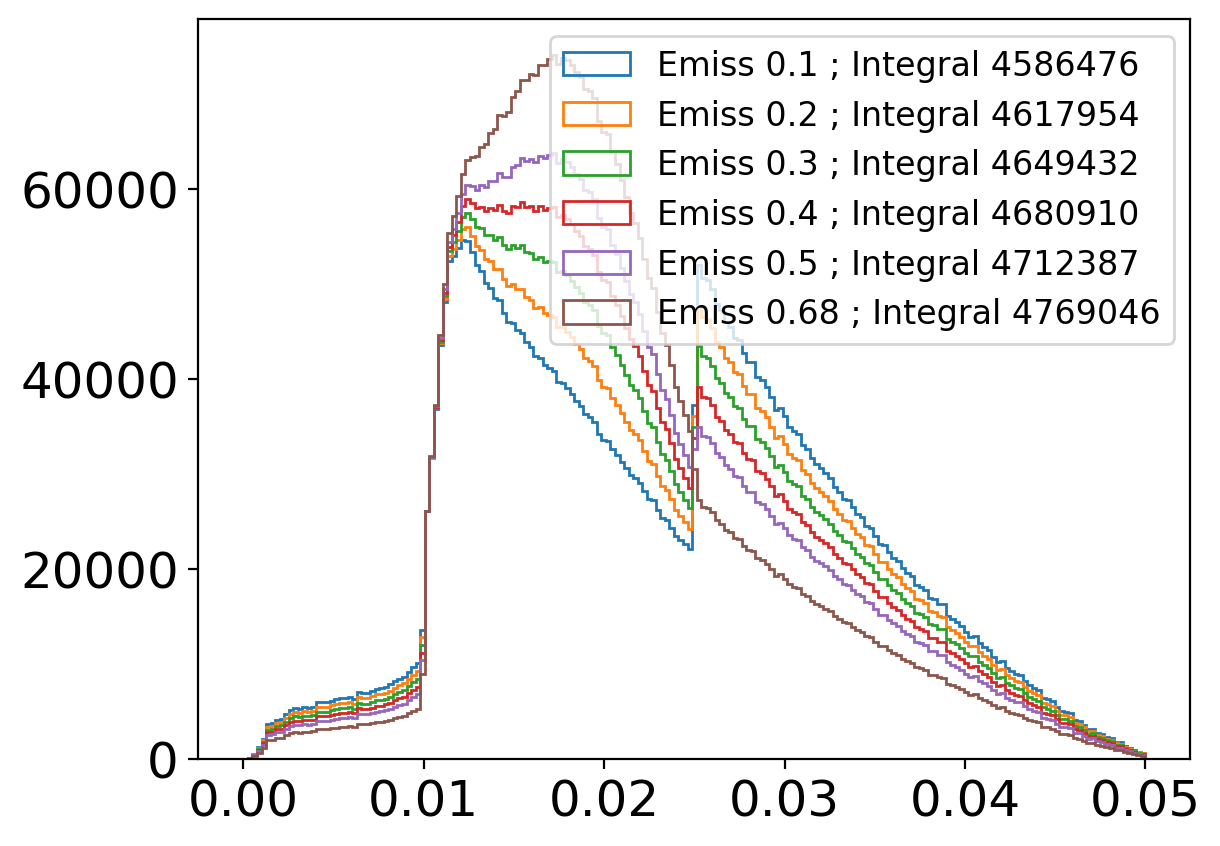

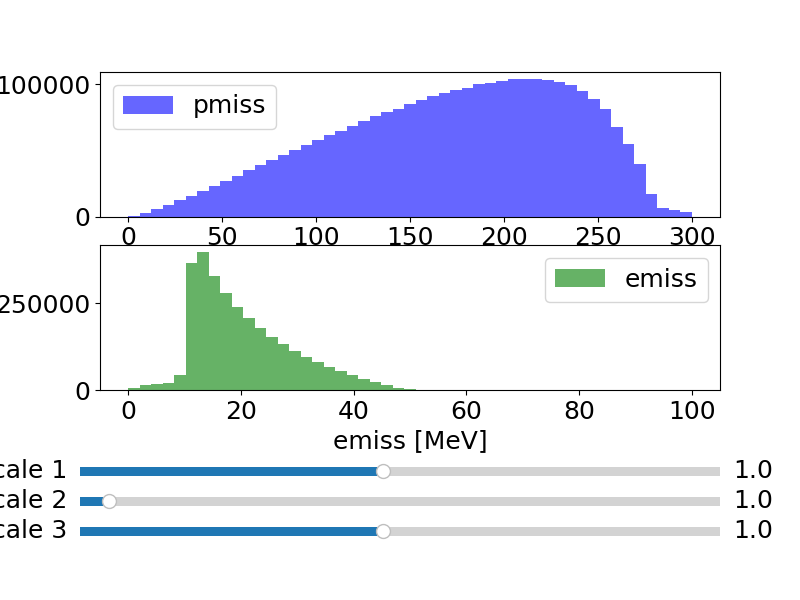

In [61]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.widgets import Slider

# Reweighting functions
def reweight_tail(E, var):
    return pl.when(E.is_between(0, 0.01)).then(var).otherwise(1)

def reweight_mean(E, var):
    return pl.when(E > 0.01).then(1 + var * E).otherwise(1)

def reweight_core(E, var):
    return pl.when(E.is_between(0.01, 0.025)).then(
        pl.max_horizontal(0.2, 1 + var * (np.pi / 10 * E / 0.001).cos())
    ).otherwise(1)

# Calculate pmiss and emiss
nucleon_mass = 0.93956542052
data = genie_ccqe.with_columns(
    pmiss=(pl.col('hitnuc_Px')**2 + pl.col('hitnuc_Py')**2 + pl.col('hitnuc_Pz')**2).sqrt(),
    emiss=nucleon_mass - pl.col('hitnuc_E')
)

# Initial plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))
plt.subplots_adjust(bottom=0.35)  # Adjust the plot to make room for the sliders

# Initial histograms
pbins = np.linspace(0, 300, 50)
ebins = np.linspace(0, 100, 50)

# Plot initial distributions
counts_pmiss, bins_pmiss, bars_pmiss = ax1.hist(data['pmiss'] * 1000, bins=pbins, color='blue', alpha=0.6, label='pmiss')
counts_emiss, bins_emiss, bars_emiss = ax2.hist(data['emiss'] * 1000, bins=ebins, color='green', alpha=0.6, label='emiss')

ax1.set_xlabel('pmiss [MeV]')
ax1.set_ylabel('Frequency')
ax1.legend()

ax2.set_xlabel('emiss [MeV]')
ax2.set_ylabel('Frequency')
ax2.legend()

# Define the slider axes
slider_ax1 = plt.axes([0.1, 0.2, 0.8, 0.03], facecolor='lightgoldenrodyellow')
slider_ax2 = plt.axes([0.1, 0.15, 0.8, 0.03], facecolor='lightgoldenrodyellow')
slider_ax3 = plt.axes([0.1, 0.1, 0.8, 0.03], facecolor='lightgoldenrodyellow')

# Create the sliders
slider1 = Slider(slider_ax1, 'Weight Scale 1', 0.1, 2.0, valinit=1.0)
slider2 = Slider(slider_ax2, 'Weight Scale 2', 0.1, 20, valinit=1.0)
slider3 = Slider(slider_ax3, 'Weight Scale 3', 0.1, 2.0, valinit=1.0)

# Update function for the sliders
def update(val, func):
    weight_scale = func(pl.col('emiss'), val)
    weighted_data = data.with_columns(weight=weight_scale)

    # Update histogram data
    counts_pmiss, _ = np.histogram(weighted_data['pmiss'] * 1000, bins=pbins, weights=weighted_data['weight'])
    counts_emiss, _ = np.histogram(weighted_data['emiss'] * 1000, bins=ebins, weights=weighted_data['weight'])

    for bar, height in zip(bars_pmiss, counts_pmiss):
        bar.set_height(height)

    for bar, height in zip(bars_emiss, counts_emiss):
        bar.set_height(height)

    ax1.relim()
    ax1.autoscale_view()
    ax2.relim()
    ax2.autoscale_view()

    fig.canvas.draw_idle()

# Connect the update function to the sliders
slider1.on_changed(lambda val: update(val, reweight_tail))
slider2.on_changed(lambda val: update(val, reweight_mean))
slider3.on_changed(lambda val: update(val, reweight_core))

plt.show()


In [38]:
relevant_systs = [
    "FrCEx_N",
    "FrInel_N",
    "FrAbs_N",
    "FrPiProd_N",
    "MFP_N",
    "ZExpA1CCQE",
    "ZExpA2CCQE",
    "ZExpA3CCQE",
    "ZExpA4CCQE"
]

with uproot.open('nusyst_new_sum.root') as f:
    syst_id = f['SRGlobal/wgts.params.id'].array(library='np')[0]
    syst_nshifts = f['SRGlobal/wgts.params.nshifts'].array(library='np')[0]
    syst_name = f['SRGlobal/wgts.params.name'].array(library='np')[0]
    
    systs_header = pl.DataFrame({
        'id': syst_id,
        'nshifts': syst_nshifts,
        'name': syst_name
    })
    
    for syst in tqdm(systs_header.iter_rows(named=True), total=len(systs_header)):
        if syst['name'] not in relevant_systs:
            continue
        variations = f['SystWeights'][syst['name']].array(library='np')
        col_names = [f'{syst["name"]}_{i}' for i in range(syst['nshifts'])]
        variations = pl.from_numpy(variations, schema=col_names)
        variations = pl.concat([genie, variations], how='horizontal')
        variations_ccqe = variations.filter(
            pl.col('proc') == '<QES - Weak[CC]>'
        )
        variations_ccqe.write_parquet(f'parquet/{syst["name"]}_ccqe.parquet')
    # systs = pl.concat(all_variations, how='horizontal')

100%|██████████| 84/84 [01:21<00:00,  1.03it/s]


In [37]:
from glob import glob
filenames = glob('parquet/ZExp*ccqe.parquet')
data = None
for fname in filenames:
    df = pl.scan_parquet(fname)
    if data is None:
        data = df
    else:
        data_keys = data.columns
        df_keys = df.columns
        common_keys = data_keys.intersect(df_keys)
        data = pl.concat([data, df.drop(common_keys)], how='horizontal')
fetched_data = data.collect()

/tmp/ipykernel_44346/242996213.py:9: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  data_keys = data.columns
/tmp/ipykernel_44346/242996213.py:10: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  df_keys = df.columns


AttributeError: 'list' object has no attribute 'intersect'

In [5]:
with uproot.open('nusyst_new_sum.root') as f:
    syst_id = f['SRGlobal/wgts.params.id'].array(library='np')[0]
    syst_nshifts = f['SRGlobal/wgts.params.nshifts'].array(library='np')[0]
    syst_name = f['SRGlobal/wgts.params.name'].array(library='np')[0]
    
    systs_header = pl.DataFrame({
        'id': syst_id,
        'nshifts': syst_nshifts,
        'name': syst_name
    })

In [43]:
relevant_systs = [
    "FrCEx_N",
    "FrInel_N",
    "FrAbs_N",
    "FrPiProd_N",
    "MFP_N",
    "ZExpA1CCQE",
    "ZExpA2CCQE",
    "ZExpA3CCQE",
    "ZExpA4CCQE"
]

from scipy.stats import binned_statistic


def plot_variations(data, syst, var, bins, logx=False, xlabel=None):
    
    plt.figure()
    nominal_index = systs_header.filter(pl.col('name') == syst)['nshifts'][0] // 2
    for idx in range(nominal_index - 1, nominal_index + 2):
        plt.hist(data.select(var), bins=bins, histtype='step', weights=data[f'{syst}_{idx}'], label=rf'{idx - nominal_index}$\sigma$', lw=2);
    if logx:
        plt.xscale('log')
    plt.legend(title=syst)
    if xlabel is not None:
        plt.xlabel(xlabel)
    else:
        plt.xlabel(var)
    plt.ylabel('# Events')
    plt.tight_layout()

def plot_variations_ratio(data, syst, var, bins, logx=False, xlabel=None):
    plt.figure()

    nominal_index = systs_header.filter(pl.col('name') == syst)['nshifts'][0] // 2
    events_var = data.select(var).to_numpy().T

    nominal = np.histogram(events_var[0], bins=bins, weights=data[f'{syst}_{nominal_index}'])[0]
    for idx in range(nominal_index - 1, nominal_index + 2):
        weights = data[f'{syst}_{idx}']
        hist = np.histogram(events_var[0], bins=bins, weights=weights)[0]
        plt.plot(bins[:-1], hist / nominal, label=rf'{idx - nominal_index:+d}$\sigma$', lw=2);
    if logx:
        plt.xscale('log')
    plt.legend(title=syst)
    if xlabel is not None:
        plt.xlabel(xlabel)
    else:
        plt.xlabel(var)
    plt.ylabel('Ratio to nominal')
    plt.tight_layout()

def plot_variations_2d(data, syst, var, bins, logx=False, logy=False, xlabel=None, ylabel=None, nb_sigmas=1):
    assert(len(var) == 2)
    assert(len(bins) == 2)
    plt.figure()

    nominal_index = systs_header.filter(pl.col('name') == syst)['nshifts'][0] // 2
    events_var = data.select(var).to_numpy().T

    nominal = np.histogram2d(events_var[0], events_var[1], bins=bins, weights=data[f'{syst}_{nominal_index}'])[0]
    assert(nominal_index + nb_sigmas < systs_header.filter(pl.col('name') == syst)['nshifts'][0])
    weights = data[f'{syst}_{nominal_index+nb_sigmas}']
    hist = np.histogram2d(events_var[0], events_var[1], bins=bins, weights=weights)[0]
    plt.pcolormesh(bins[0], bins[1], (hist / nominal).T, cmap='jet', shading='auto', alpha=1);
    plt.colorbar()
    # plt.imshow(hist / nominal, extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]]);
    if logx:
        plt.xscale('log')
    if logy:
        plt.yscale('log')
    plt.legend(title=syst)
    if xlabel is not None:
        plt.xlabel(xlabel)
    else:
        plt.xlabel(var[0])
    if ylabel is not None:
        plt.ylabel(ylabel)
    else:
        plt.ylabel(var[1])
    plt.title(rf'({nb_sigmas:+}$\sigma$)Ratio to nominal')
    plt.tight_layout()

# def plot_variations_resolution(data, syst, var1, var2, bins, logx=False):
#     plt.figure()

#     def weighted_std(sample, weights):
#         return np.std(sample, weights=weights)

#     nominal_index = systs_header.filter(pl.col('name') == syst)['nshifts'][0] // 2
#     for idx in range(nominal_index - 1, nominal_index + 2):
#         weights = data[f'{syst}_{idx}'].to_numpy().flat
#         # std = binned_statistic(data.select(var1).to_numpy().flat, data.select(var2).to_numpy().flat, statistic='std', bins=bins).statistic
#         std = binned_statistic(data.select(var1).to_numpy().flat, data.select(var2).to_numpy().flat, statistic=lambda x: weighted_std(x, weights[np.in1d(data, x)]), bins=bins).statistic
#         plt.errorbar(0.5*(bins[:-1] + bins[1:]), std, fmt='o', label=rf'{idx - nominal_index}$\sigma$', lw=2)
#     if logx:
#         plt.xscale('log')
#     plt.legend(title=syst)
#     plt.xlabel(var1)
#     plt.ylabel(var2)
#     plt.tight_layout()

    

# plot_variations_ratio(cc_qe, "ZExpA1CCQE", 'nu_E', np.linspace(0.1, 1, 50),)
for param in tqdm(relevant_systs):
    nshifts = systs_header.filter(pl.col('name') == param)['nshifts'][0]
    if nshifts <= 2:
        continue
    fetched_data = pl.read_parquet(f'parquet/{param}_ccqe.parquet').with_columns(
        direc_true = pl.col('nu_Py')/pl.col('nu_E'),
        direc_reco = pl.when(pl.col('Pmu_y') != 0).then(pl.col('Pmu_y')).otherwise(pl.col('Pe_y')),
        pmiss = (pl.col('hitnuc_Px')**2 + pl.col('hitnuc_Py')**2 + pl.col('hitnuc_Pz')**2).sqrt()*1000,
    ).with_columns(
        direc_res = (pl.col('direc_reco').arccos() - pl.col('direc_true').arccos())*180/np.pi,
        Erec = pl.when(pl.col('pdg').abs() == 14).then(pl.col('Elep_calo')).otherwise(pl.col('Ee_calo')),
    ).filter(
        pl.col('direc_reco').abs() <= 1,
    )
    plot_variations(fetched_data, param, 'nu_E', np.linspace(0.1, 2, 50),)
    plt.savefig(f'plots/{param}_nu_E.png', dpi=300)
    plt.close()
    plot_variations_ratio(fetched_data, param, 'nu_E', np.linspace(0.1, 2, 50),)
    plt.savefig(f'plots/{param}_nu_E_ratio.png', dpi=300)
    plt.close()

    plot_variations(fetched_data, param, 'Q2', np.linspace(0, 2, 50),)
    plt.savefig(f'plots/{param}_Q2.png', dpi=300)
    plt.close()
    plot_variations_ratio(fetched_data, param, 'Q2', np.linspace(0, 2, 50),)
    plt.savefig(f'plots/{param}_Q2_ratio.png', dpi=300)
    plt.close()

    plot_variations(fetched_data, param, 'Erec', np.linspace(0.1, 2, 50),)
    plt.savefig(f'plots/{param}_Erec.png', dpi=300)
    plt.close()
    plot_variations_ratio(fetched_data, param, 'Erec', np.linspace(0.1, 2, 50),)
    plt.savefig(f'plots/{param}_Erec_ratio.png', dpi=300)
    plt.close()

    plot_variations(fetched_data, param, pl.col('nu_E') - pl.col('Erec'), np.linspace(0.1, 2, 50), xlabel='Enu - Erec')
    plt.savefig(f'plots/{param}_Eres.png', dpi=300)
    plt.close()
    plot_variations_ratio(fetched_data, param, pl.col('nu_E') - pl.col('Erec'), np.linspace(0.1, 2, 50), xlabel='Enu - Erec')
    plt.savefig(f'plots/{param}_Eres_ratio.png', dpi=300)
    plt.close()

    plot_variations(fetched_data, param, 1 - pl.col('Erec')/pl.col('nu_E'), np.linspace(-1, 1, 50), xlabel='1 - Erec/Enu')
    plt.savefig(f'plots/{param}_Eresrel.png', dpi=300)
    plt.close()
    plot_variations_ratio(fetched_data, param, 1 - pl.col('Erec')/pl.col('nu_E'), np.linspace(-1, 1, 50), xlabel='1 - Erec/Enu')
    plt.savefig(f'plots/{param}_Eresrel_ratio.png', dpi=300)
    plt.close()

    plot_variations_2d(fetched_data, param, ['q0', 'q3'] , [np.linspace(0, 1.5, 40), np.linspace(0, 1.5, 40)], nb_sigmas=1)
    plt.savefig(f'plots/{param}_2d_q0q3_+1_ratio.png', dpi=300)
    plt.close()
    plot_variations_2d(fetched_data, param, ['q0', 'q3'] , [np.linspace(0, 1.5, 40), np.linspace(0, 1.5, 40)], nb_sigmas=-1)
    plt.savefig(f'plots/{param}_2d_q0q3_-1_ratio.png', dpi=300)
    plt.close()

    plot_variations_2d(fetched_data, param, [1 - pl.col('Erec')/pl.col('nu_E'), 'direc_res'] , [np.linspace(-1, 1, 40), np.linspace(-180, 180, 40)], nb_sigmas=1, xlabel='1 - Erec/Enu')
    plt.savefig(f'plots/{param}_2d_EresThetares_+1_ratio.png', dpi=300)
    plt.close()
    plot_variations_2d(fetched_data, param, [1 - pl.col('Erec')/pl.col('nu_E'), 'direc_res'] , [np.linspace(-1, 1, 40), np.linspace(-180, 180, 40)], nb_sigmas=-1, xlabel='1 - Erec/Enu')
    plt.savefig(f'plots/{param}_2d_EresThetares_-1_ratio.png', dpi=300)
    plt.close()
    
    # plot_variations_2d(fetched_data, param, ['Erec', 'direc_res'] , [np.linspace(0.1, 2, 15), np.linspace(-2, 2, 15)],)
    # plt.savefig(f'plots/{param}_2d_ratio.png', dpi=300)
    # plt.close()
    # plot_variations_resolution(fetched_data, param, 'nu_E', 'direc_res', np.linspace(0.1, 2, 50),)
    # plt.savefig(f'plots/{param}_nu_E_dirRes.pdf')
    # plt.close()
    plot_variations(fetched_data, param, 'direc_res', np.linspace(-180, 180, 50),)
    plt.savefig(f'plots/{param}_dirRes.png', dpi=300)
    plt.close()
    plot_variations_ratio(fetched_data, param, 'direc_res', np.linspace(-180, 180, 50),)
    plt.savefig(f'plots/{param}_dirRes_ratio.png', dpi=300)
    plt.close()
# plot_variations(cc_qe, "ZExpA1CCQE", (pl.col('hitnuc_Px')**2 + pl.col('hitnuc_Py')**2 + pl.col('hitnuc_Pz')**2).sqrt(), np.linspace(0, 0.3, 50))
# plot_variations_2d(cc_qe, "ZExpA1CCQE", [nucleon_mass - pl.col('hitnuc_E'), (pl.col('hitnuc_Px')**2 + pl.col('hitnuc_Py')**2 + pl.col('hitnuc_Pz')**2).sqrt()], [np.linspace(0, 0.1, 50), np.linspace(0, 0.3, 50)])

  0%|          | 0/9 [00:00<?, ?it/s]

/tmp/ipykernel_97193/3046004221.py:65: RuntimeWarning: invalid value encountered in divide
  plt.pcolormesh(bins[0], bins[1], (hist / nominal).T, cmap='jet', shading='auto', alpha=1);
/tmp/ipykernel_97193/3046004221.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=syst)
100%|██████████| 9/9 [01:19<00:00,  8.80s/it]


/tmp/ipykernel_228208/3333206680.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=syst)


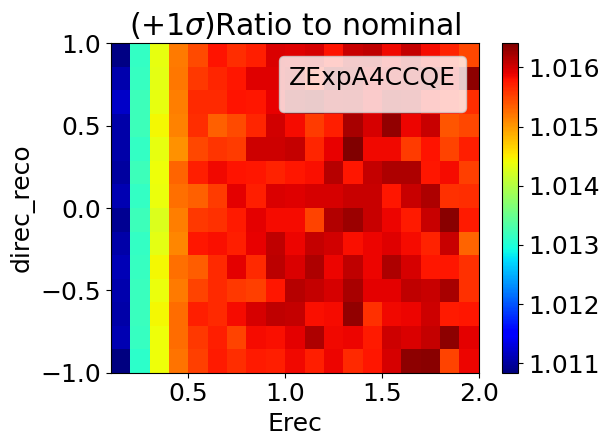

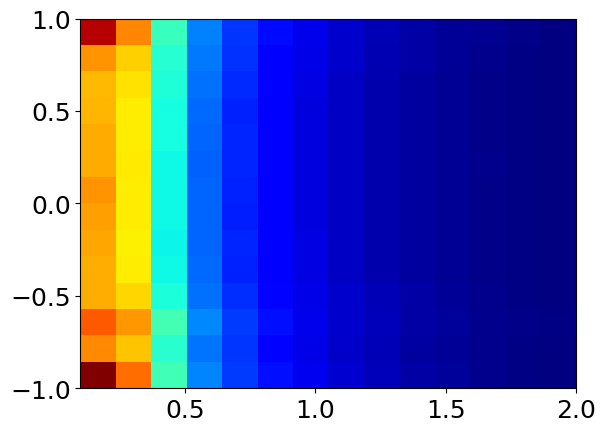

In [79]:
plot_variations_2d(fetched_data, param, ['Erec', 'direc_reco'] , [np.linspace(0.1, 2, 20), np.linspace(-1, 1, 15)],)
plt.figure()
plt.hist2d(fetched_data['Erec'], fetched_data['direc_reco'], bins=[np.linspace(0.1, 2, 15), np.linspace(-1, 1, 15)], cmap='jet');

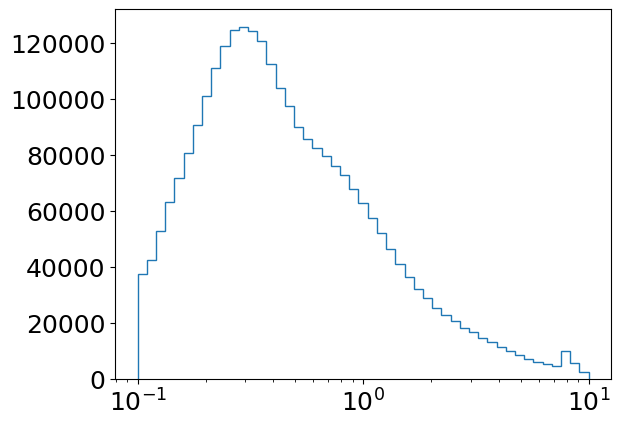

In [83]:
plt.hist(fetched_data['Erec'], bins=np.logspace(-1, 1, 50), histtype='step');
plt.xscale('log')

In [25]:
all_data = fetchedgeniea.join(reco, on=['EventID', 'SubRun', 'Run'])

NameError: name 'fetched_datgeniea' is not defined

In [20]:
fetched_data.columns

['isCC',
 'lep_Px',
 'lep_Py',
 'lep_Pz',
 'lep_E',
 'nu_Px',
 'nu_Py',
 'nu_Pz',
 'nu_E',
 'hitnuc_Px',
 'hitnuc_Py',
 'hitnuc_Pz',
 'hitnuc_E',
 'removalE',
 'proc',
 'ZExpA1CCQE_0',
 'ZExpA1CCQE_1',
 'ZExpA1CCQE_2',
 'ZExpA1CCQE_3',
 'ZExpA1CCQE_4',
 'ZExpA1CCQE_5',
 'ZExpA1CCQE_6',
 'ZExpA3CCQE_0',
 'ZExpA3CCQE_1',
 'ZExpA3CCQE_2',
 'ZExpA3CCQE_3',
 'ZExpA3CCQE_4',
 'ZExpA3CCQE_5',
 'ZExpA3CCQE_6',
 'ZExpA2CCQE_0',
 'ZExpA2CCQE_1',
 'ZExpA2CCQE_2',
 'ZExpA2CCQE_3',
 'ZExpA2CCQE_4',
 'ZExpA2CCQE_5',
 'ZExpA2CCQE_6',
 'ZExpA4CCQE_0',
 'ZExpA4CCQE_1',
 'ZExpA4CCQE_2',
 'ZExpA4CCQE_3',
 'ZExpA4CCQE_4',
 'ZExpA4CCQE_5',
 'ZExpA4CCQE_6']

In [26]:
data.filter(
    pl.col('emiss') < 0
)

isCC,lep_Px,lep_Py,lep_Pz,lep_E,nu_Px,nu_Py,nu_Pz,nu_E,hitnuc_Px,hitnuc_Py,hitnuc_Pz,hitnuc_E,removalE,proc,pmiss,emiss
i32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,f32,f32
1,-0.019645,0.129711,0.085025,0.18869,0.445227,0.011423,-0.252021,0.511731,-0.361589,-0.211632,0.086057,1.925895,0.0,"""<MEC - Weak[CC]>""",0.427716,-0.98633
1,-0.603193,-0.520038,-1.719412,1.897847,-1.340155,-0.830639,-1.869334,2.44547,-0.076159,-0.33266,-0.031756,1.908823,0.0,"""<MEC - Weak[CC]>""",0.342741,-0.969257
1,0.132909,0.177782,0.19115,0.311406,-0.257814,0.468049,-0.039516,0.535816,-0.028721,0.037635,-0.019864,1.879801,0.0,"""<MEC - Weak[CC]>""",0.051341,-0.940236
1,-0.221213,0.026111,-0.102509,0.267,-0.44183,0.293503,-0.121899,0.544256,0.031576,0.143631,-0.00908,1.883572,0.0,"""<MEC - Weak[CC]>""",0.14734,-0.944006
1,0.475059,0.016827,-0.703338,0.85546,1.031374,0.604164,-0.590476,1.333188,-0.421138,0.002746,0.068215,1.925656,0.0,"""<MEC - Weak[CC]>""",0.426635,-0.98609
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1,-0.374126,-0.505322,-0.173193,0.660667,-0.451456,-0.303891,0.744513,0.922199,0.128183,0.105359,-0.081649,1.888178,0.0,"""<MEC - Weak[CC]>""",0.184927,-0.948612
1,-0.083445,0.047039,-0.26078,0.29723,0.785207,-0.14866,-0.375983,0.883179,-0.220441,-0.190061,0.054897,1.901017,0.0,"""<MEC - Weak[CC]>""",0.296195,-0.961451
1,-0.202292,-0.158236,-0.007477,0.277813,-0.084079,-0.715518,-0.134786,0.732941,0.045717,-0.085585,-0.180767,1.888974,0.0,"""<MEC - Weak[CC]>""",0.205162,-0.949409
